we have 3 files to use- adt raw csv
fate readout csv at barcode lvl 
x rna counts mtx 

subset to hsc . find hvgs . 
use the fate readout csv to classify in terms of fate what barcode lineages are unipotent 
broadcast those lineages onto every cell in the barcode lineage
this is the basis of our groups = True in mofa. We will run with some larger groups first- ery / Mast [largest presence iirc] / cDC1 VS multipotent . see wht makes these JUST ery and not multipotent. so run w groups=True for group= i for all i in celltypes . 

to check if this has worked, check the variance explained per factor in the data. 

if it doesnt work: try run on all data and not just hscs 

In [18]:
import pandas as pd
import scanpy as sc 
import numpy as np 

In [19]:
adt_counts = pd.read_csv("/vast/projects/Sisseq/givanna/making_sense_of_files/adt_raw.csv")

print(adt_counts.head())
print(adt_counts.columns.to_list())

# important here -> protein is column , cell is row so (cell x protien)



   Unnamed: 0                cell  Hu.CD134  Hu.CD112  Hu.HLA.DR  Hu.CD115  \
0           1  AAACCCAAGGTTAAAC-1         0        25         19         1   
1           2  AAACCCACAAATCAAG-1         0         8         18         3   
2           3  AAACCCACAAGTATCC-1         0         8          7         0   
3           4  AAACCCACAGGTTACT-1         0         9         13         2   
4           5  AAACCCACATGATCTG-1         0        14          1        13   

   Hu.CD279  Hu.CD37  Hu.CD99  Hu.LOX.1  ...  RNA.weight  ADT.weight  \
0         0        0        9         0  ...    0.529892    0.470108   
1         0        0       16         0  ...    0.603510    0.396490   
2         1        0        5         1  ...    0.657347    0.342653   
3         0        0       13         2  ...    0.423450    0.576550   
4         3        0        3         1  ...    0.525541    0.474459   

   wsnn_res.2  seurat_clusters  wsnn_res.1  predicted.celltype.score  \
0          10             

In [20]:
num_barcodes = adt_counts["cons_bc"].nunique()

print("number of unique barcodes is : ", num_barcodes)

adt_counts["cons_bc"].head() # length of 20. the subsequent analysis has the length to be subset to 15 and donor id to be added here for analysis

number of unique barcodes is :  3066


0    GTCTCGTTCTGGGTGGTAGT
1                     NaN
2                     NaN
3    CCCTGGTTGTCTGTGTTTGT
4    AGGAGGGACATTCAGGGACT
Name: cons_bc, dtype: object

In [21]:
adt_obj = adt_counts

adt_obj["cons_bc"] = adt_counts["cons_bc"].str[:15]
adt_obj["barcode_donor"] = adt_obj["cons_bc"].str.cat(adt_counts['donor_id'], sep='_')

len(adt_obj["barcode_donor"])
adt_obj["barcode_donor"].head(30)

# no. of barcodes after subsetting and attaching donor - 9768
# lots of NA values. try dropNA ? 

adt_obj["barcode_donor"].isna().sum() # 4259 are NA 
adt_obj = adt_obj[adt_obj["barcode_donor"].notna()]
adt_obj["barcode_donor"].isna().sum()
len(adt_obj["barcode_donor"]) # 5509 barcodes remaining

5509

In [22]:
# subsetting adt_obj to hscs 
print(adt_obj['populations'].head())
adt_obj = adt_obj[adt_obj["populations"] == "HSC"]
len(adt_obj)

# no. left are now 439 

0                           Mk
3                           Mk
4    early_lymphoid_progenitor
6                           Mk
7                  Mk-ery_prog
Name: populations, dtype: object


439

In [23]:
# now should have the same barcodes for fate and X_rna 

fate_obj = pd.read_csv("/vast/projects/Sisseq/givanna/making_sense_of_files/fate_readout.csv")
fate_obj.columns # (barcode x day_PX for X in A,B,C)
fate_obj.head() # we have barcode_first_15_bp 

# tryig to overlap the barcode_donor col of the prev dataset with the bcode_first_15bp of this dataset 

overlap = set(adt_obj["barcode_donor"]) & set(fate_obj["bcode_first_15bp"])

print(f"Number of overlapping barcodes: {len(overlap)}")
print(list(overlap)[:20])

print(fate_obj["bcode_first_15bp"].head())
adt_obj["barcode_donor"].head()

# we are stuck at 112 again. Number of overlapping barcodes: 112

# abandon this and work on the 439 for now. 


Number of overlapping barcodes: 112
['GGCTGGGACATAGTG_1', 'AGCTCAGTGTAGGAG_1', 'TAGAGTTAGAACGAG_1', 'CACCAATCTATCAAG_U', 'TTCAGTAACTGTGTC_1', 'AAGCCATGGTTCATA_U', 'TTGTGGTTCTGTGTC_P', 'CAGCCAACATGCAAG_U', 'ACGACGCTCTAGGAC_1', 'TAAGCATGGATGTTA_U', 'TGGTGGTAGTTAGAG_1', 'CACGGACGTTGCTTA_U', 'TCGACGTTCAGACAC_1', 'CACTGGTAGTAAGAG_1', 'CCGAGTCTCAATCTG_1', 'CAACAATCTCAATGA_V', 'TTTCTATGAGAAACA_V', 'GAGCTTACCAACATT_U', 'TCGAGATTCATCCTC_1', 'TTGTCCTTCTTAGAG_1']
0    AAACAAACGAGGGAT_U
1    AAACAAACTTGGAAT_U
2    AAACAAAGTAGGCAG_U
3    AAACAAGCGTAGTAG_U
4    AAACAAGGCTCGGAG_U
Name: bcode_first_15bp, dtype: object


28     CTGCCTGGCTTCGTA_1
86     ACCTGGGTGAGWGTG_1
87     TTGACCAAGATTGTG_1
150    TTCTGAGAGTCGCTG_1
151    AACTGACACACAGTG_1
Name: barcode_donor, dtype: object

In [24]:
# reading rna counts scanpy

rna_counts = sc.read_mtx("/vast/projects/Sisseq/givanna/making_sense_of_files/X_rna_counts.mtx") # of type andata 

print(rna_counts)
# just intersect w adt_obj. 

AnnData object with n_obs × n_vars = 9768 × 36601


In [25]:
import anndata as ad
from scipy.sparse import csr_matrix

In [26]:
rna_counts.X

<9768x36601 sparse matrix of type '<class 'numpy.float32'>'
	with 44068873 stored elements in Compressed Sparse Row format>

In [27]:
rna_counts.obsnames = [f"Cell_{i:d}" for i in range(rna_counts.n_obs)]
rna_counts.obs_names[:10]

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype='object')

trying to use nmf t group barcodes into respective lineages, then project the linege unipotent identity onto every cell under that lineage. when trying to use a 70% filter threshold on picking the lineages we ended up with highly unbalanced cell counts: 

group_label
multipotent    1289
Ery            1148
Mast           1019
Rest            537
Mye             491
cDC2            273
pDC             142
Lymph            76
cDC1             59

and hence mofa was skewed. retrying w nmf to group. 

In [28]:
#fate_obj.columns
#.columns.tolist()

from sklearn.decomposition import NMF
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
fate_obj # 5034 barcodes 
len(fate_obj["bcode_first_15bp"].unique().tolist()) # all len 15 are unique 5034 so we are trying to run nmf on 5034 barcodes

5034

In [41]:

LINEAGE_NAMES = ["Ery", "Lymph", "Mast", "Mye", "Rest", "cDC1", "cDC2", "pDC"]
DAYS = [7, 10, 14, 21]

# easiest to jojn on first 15 as common ident
fate_idx = fate_obj.set_index("bcode_first_15bp")

# barcode x (lineage, day) 2d for nmf
wide = pd.DataFrame(index=fate_idx.index)

for day in DAYS:
    for lin in LINEAGE_NAMES:
        cols = [
            c for c in fate_idx.columns
            if c.startswith(f"D{day}_{lin}_")
        ]

        if cols:
            wide[(lin, f"D{day}")] = (
                fate_idx[cols]
                .clip(lower=0)
                .mean(axis=1)
            )
        else:
            wide[(lin, f"D{day}")] = 0

wide.columns = pd.MultiIndex.from_tuples(
    wide.columns,
    names=["lineage", "day"]
)

print(wide.shape)
wide.head()

(5034, 32)


lineage,Ery,Lymph,Mast,Mye,Rest,cDC1,cDC2,pDC,Ery,Lymph,...,cDC2,pDC,Ery,Lymph,Mast,Mye,Rest,cDC1,cDC2,pDC
day,D7,D7,D7,D7,D7,D7,D7,D7,D10,D10,...,D14,D14,D21,D21,D21,D21,D21,D21,D21,D21
bcode_first_15bp,,,,,,,,,,,,,,,,,,,,,
AAACAAACGAGGGAT_U,626.933894,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
AAACAAACTTGGAAT_U,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,1051.070851,0.0,0.0,0.0,0.0,0.000000
AAACAAAGTAGGCAG_U,0.000000,0.0,0.0,0.0,1.381451,0.0,0.509217,0.257293,0.00000,253.907521,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,3339.249011
AAACAAGCGTAGTAG_U,412.641198,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,531.70102,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
AAACAAGGCTCGGAG_U,0.000000,0.0,0.0,0.0,0.000000,0.0,299.950694,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000


In [42]:
X = wide.fillna(0).clip(lower=0).values

N_CLUSTERS = 12 # 8 + 2 multi + all celltype we can also try 9 for a cleaner one

nmf = NMF(
    n_components=N_CLUSTERS,
    init="nndsvda",
    random_state=42,
    max_iter=1000
)

W = nmf.fit_transform(X)
H = nmf.components_

cluster_assignment = W.argmax(axis=1)

barcode_cluster_df = pd.DataFrame({
    "barcode": wide.index,
    "cluster": cluster_assignment,
})

print(
    barcode_cluster_df["cluster"]
    .value_counts()
    .sort_index()
)

sum(barcode_cluster_df["cluster"].value_counts())

cluster
0      701
1      196
2      575
3       63
4       53
5      213
6     1295
7       48
8     1821
9       43
11      26
Name: count, dtype: int64


5034

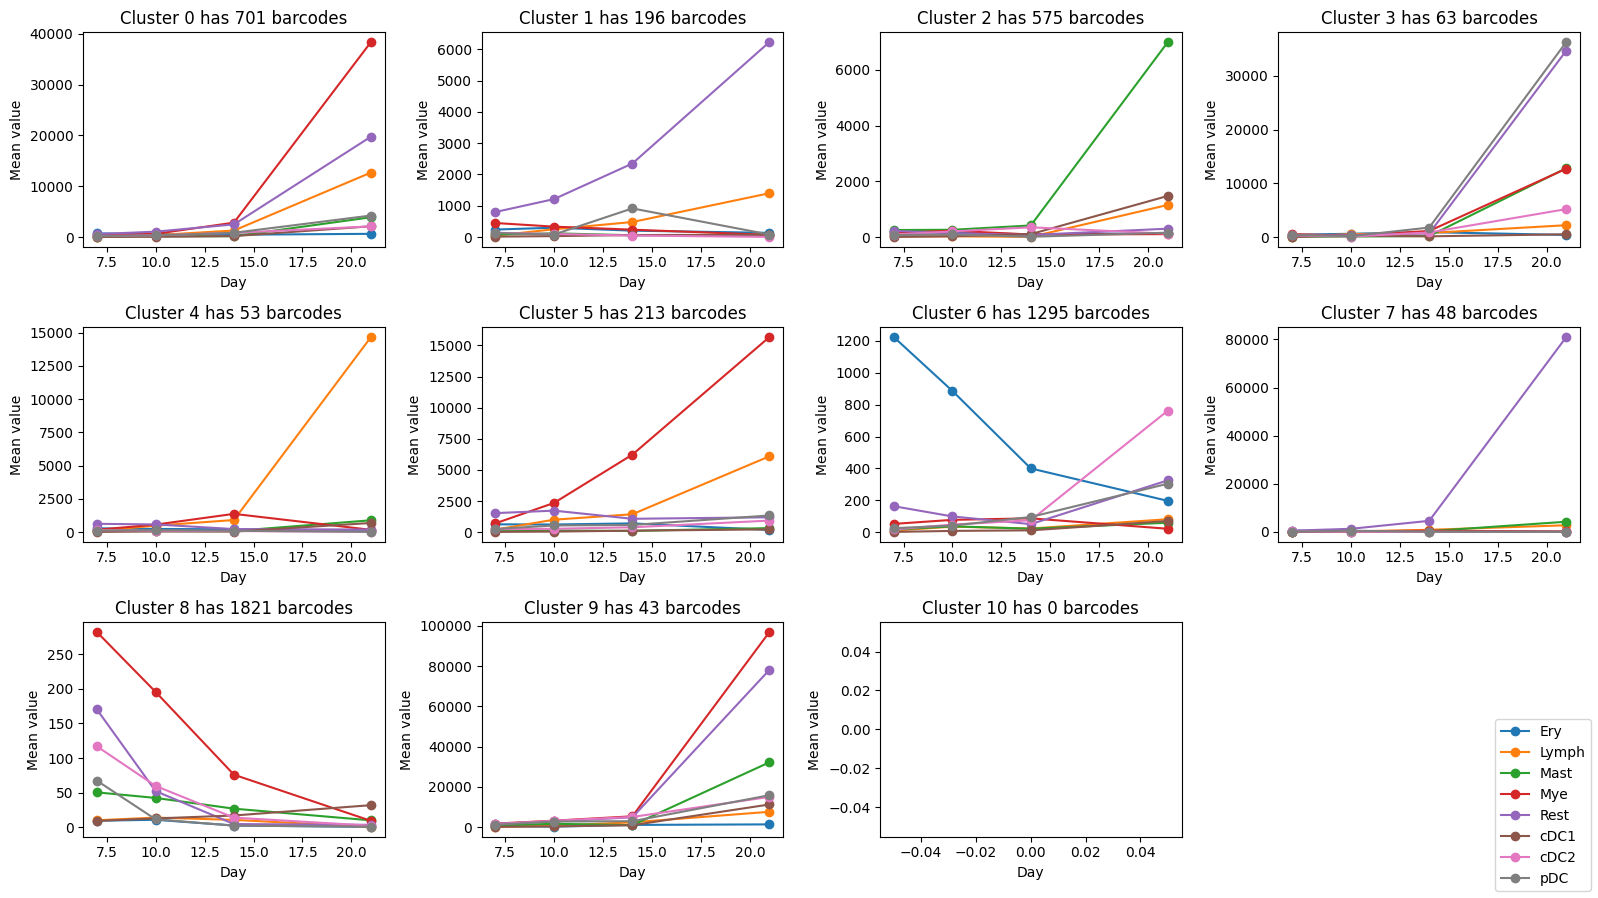

In [44]:
# plotting the day graphs

days_sorted = [f"D{d}" for d in DAYS]

n_clusters_actual = barcode_cluster_df["cluster"].nunique()
n_cols = 4
n_rows = int(np.ceil(n_clusters_actual / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 3 * n_rows)
)

axes = np.asarray(axes).flatten()

for i in range(n_clusters_actual):
    ax = axes[i]

    members = barcode_cluster_df.loc[
        barcode_cluster_df["cluster"] == i,
        "barcode"
    ]

    n_bc = len(members)

    for lin in LINEAGE_NAMES:
        vals = wide.loc[members, lin][days_sorted].mean(axis=0)

        ax.plot(
            [7, 10, 14, 21],
            vals.values,
            marker="o",
            label=lin
        )

    ax.set_title(f"Cluster {i} has {n_bc} barcodes")
    ax.set_xlabel("Day")
    ax.set_ylabel("Mean value")

for j in range(n_clusters_actual, len(axes)):
    fig.delaxes(axes[j])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right")

plt.tight_layout()
plt.show()


## Methodology update (read this before continuing)

Two changes from the original plan in the first markdown cell above:

1. **MOFA groups.** We are **not** passing `groups=True` / per-celltype groups into the
   model. In MOFA, `groups` only lets factor *scores* (Z) and *variance explained* differ
   per group — the feature *loadings* (W) are always shared across groups. That means
   grouped MOFA can never surface "genes that make a clone ery vs multipotent," because
   there's no per-group weight matrix to mine. Instead:
   - MOFA is fit **once, at single-cell resolution, with a single group** (`groups=False`,
     or one dummy group covering every cell). This is what satisfies the "must run at
     single-cell level" constraint.
   - The clonal fate label (Ery / multipotent / etc., from NMF below) is kept as **cell
     metadata only** — never passed into the model — and used **post-hoc** to test which
     factors' scores differ between fate categories.

2. **Fate labels.** Instead of a hard 70% output-threshold per barcode (which gave the
   badly skewed group sizes noted in the NMF markdown cell), barcode-level fate labels
   come from the NMF clustering below, with clusters classified as "unipotent-X" or
   "multipotent" based on how concentrated their lineage-output profile is (a soft rule,
   not a hand-picked cutoff). A raw-count Dirichlet-multinomial test is sketched at the
   end as an optional, statistically cleaner replacement for the NMF label, if
   `fate_readout.csv` turns out to hold raw sorted-fraction read counts rather than
   already-normalised values.

Pipeline from here: **NMF clustering (done above) → collapse clusters into
ery/multipotent labels → link barcode → cell → build single-group MOFA input (RNA + ADT)
→ fit MOFA → post-hoc factor-vs-fate test → pull candidate features → validate with
direct DE → (optional) refine labels with Dirichlet-multinomial.**

## Step 2b — Collapse NMF clusters into fate labels

Rather than eyeballing which of the `N_CLUSTERS` NMF components is "ery" vs
"multipotent" from the day-graphs above, we classify programmatically: for each cluster,
take its members' mean lineage-output profile (summed over `DAYS`), and look at how much
of the output is concentrated in the single dominant lineage.

- If the top lineage carries more than `DOMINANCE_THRESHOLD` of a cluster's total output,
  label the cluster by that lineage (e.g. `"Ery"`).
- Otherwise the cluster is broadly spread across lineages -> label it `"multipotent"`.

Sanity-check the printed table against the day-graphs from cell 16 before trusting it —
if a cluster's automatic label disagrees with what the plot obviously shows, override it
in `CLUSTER_LABEL_OVERRIDES` below rather than changing the threshold globally.

In [ ]:
DOMINANCE_THRESHOLD = 0.5  # fraction of total output the top lineage must carry
                            # to call a cluster "unipotent" rather than "multipotent"

# manual overrides if a cluster's automatic call disagrees with the day-graphs in cell 16
# e.g. CLUSTER_LABEL_OVERRIDES = {3: "multipotent"}
CLUSTER_LABEL_OVERRIDES = {}

cluster_profiles = {}
cluster_auto_label = {}

for cl in sorted(barcode_cluster_df["cluster"].unique()):
    members = barcode_cluster_df.loc[barcode_cluster_df["cluster"] == cl, "barcode"]

    # total output per lineage, summed across days and members
    lineage_totals = pd.Series(0.0, index=LINEAGE_NAMES)
    for lin in LINEAGE_NAMES:
        lineage_totals[lin] = wide.loc[members, lin][days_sorted].sum().sum()

    total = lineage_totals.sum()
    if total <= 0:
        cluster_auto_label[cl] = "multipotent"
        cluster_profiles[cl] = lineage_totals
        continue

    top_lineage = lineage_totals.idxmax()
    top_share = lineage_totals[top_lineage] / total

    cluster_auto_label[cl] = (
        top_lineage if top_share >= DOMINANCE_THRESHOLD else "multipotent"
    )
    cluster_profiles[cl] = lineage_totals

cluster_label_df = pd.DataFrame({
    "cluster": list(cluster_auto_label.keys()),
    "auto_label": list(cluster_auto_label.values()),
})
cluster_label_df["final_label"] = cluster_label_df.apply(
    lambda r: CLUSTER_LABEL_OVERRIDES.get(r["cluster"], r["auto_label"]), axis=1
)
cluster_label_df["n_barcodes"] = cluster_label_df["cluster"].map(
    barcode_cluster_df["cluster"].value_counts()
)

print(cluster_label_df.sort_values("cluster").to_string(index=False))

In [ ]:
# barcode-level fate label table: barcode -> group_label (Ery / Mast / ... / multipotent)
cluster_to_label = dict(zip(cluster_label_df["cluster"], cluster_label_df["final_label"]))

barcode_fate_df = barcode_cluster_df.copy()
barcode_fate_df["group_label"] = barcode_fate_df["cluster"].map(cluster_to_label)

print(barcode_fate_df["group_label"].value_counts())

# for the primary ery-vs-multipotent question, everything that isn't Ery or multipotent
# is set aside as a secondary/exploratory category (small n, low power - see chat)
PRIMARY_LABELS = ["Ery", "multipotent"]
barcode_fate_df["is_primary_contrast"] = barcode_fate_df["group_label"].isin(PRIMARY_LABELS)
print()
print("Primary contrast (Ery vs multipotent) barcode counts:")
print(barcode_fate_df.loc[barcode_fate_df["is_primary_contrast"], "group_label"].value_counts())

## Step 2c — Link `cons_bc` to individual cells, then broadcast fate labels

Turns out no new export is needed. Per Givanna's prep script
(`ST223.annotated_2024.rds` -> csv/mtx export), `adt_raw.csv` (loaded as `adt_counts` in
cell 2) already carries a `cell` column — the exact `colnames(st223_annotated_2024)`
barcode, which is the **same identifier space** as `X_rna_counts_cell_ids.txt`, since RNA
and ADT counts were both exported from that one Seurat object over the same cell
universe. So `adt_counts[["cell", "cons_bc", "donor_id"]]` **is** the cell -> `cons_bc`
join table.

Two things to fix on the RNA-loading side before this will work:

1. **Original cell 10 (`rna_counts.obsnames = [f"Cell_{i:d}" ...]`) needs to not be
   re-run** — it overwrites the real barcodes with placeholders (and `obsnames` isn't
   even a real AnnData attribute, so it silently did nothing useful anyway). We reload
   `rna_counts` properly below, with real cell IDs and gene names attached.
2. `sc.read_mtx` on its own never attached `X_rna_counts_gene_names.txt` /
   `X_rna_counts_cell_ids.txt` — reload with those explicitly.

In [ ]:
import scipy.io as sio

X = sio.mmread(
    "/vast/projects/Sisseq/givanna/making_sense_of_files/X_rna_counts.mtx"
).tocsr()

gene_names = pd.read_csv(
    "/vast/projects/Sisseq/givanna/making_sense_of_files/X_rna_counts_gene_names.txt",
    header=None
)[0].tolist()

cell_ids = pd.read_csv(
    "/vast/projects/Sisseq/givanna/making_sense_of_files/X_rna_counts_cell_ids.txt",
    header=None
)[0].tolist()

assert X.shape == (len(cell_ids), len(gene_names)), (
    f"shape mismatch: X is {X.shape}, expected ({len(cell_ids)}, {len(gene_names)}) "
    f"-- if this fails, X may need X = X.T"
)

rna_counts = ad.AnnData(
    X=X,
    obs=pd.DataFrame(index=cell_ids),
    var=pd.DataFrame(index=gene_names),
)
print(rna_counts)

In [ ]:
# cell -> cons_bc / donor_id join table, straight from the ADT export (no new file needed)
cell_to_meta = (
    adt_counts[["cell", "cons_bc", "donor_id"]]
    .drop_duplicates(subset="cell")
    .set_index("cell")
)

# sanity check the two ID spaces actually look alike before trusting the join
print("RNA cell_ids  :", rna_counts.obs_names[:5].tolist())
print("ADT 'cell' ids:", cell_to_meta.index[:5].tolist())

rna_counts.obs["cons_bc"] = rna_counts.obs_names.map(cell_to_meta["cons_bc"]).str[:15]
rna_counts.obs["donor_id"] = rna_counts.obs_names.map(cell_to_meta["donor_id"])
rna_counts.obs["barcode_donor"] = (
    rna_counts.obs["cons_bc"].str.cat(rna_counts.obs["donor_id"], sep="_")
)

n_matched = rna_counts.obs["cons_bc"].notna().sum()
print(f"{n_matched} / {rna_counts.n_obs} RNA cells matched to a cons_bc "
      f"({n_matched / rna_counts.n_obs:.1%})")
rna_counts.obs.head()

In [ ]:
# broadcast barcode-level fate label onto every cell that shares that barcode
barcode_to_group = dict(zip(barcode_fate_df["barcode"], barcode_fate_df["group_label"]))

rna_counts.obs["fate_group"] = rna_counts.obs["cons_bc"].map(barcode_to_group)

n_labelled = rna_counts.obs["fate_group"].notna().sum()
print(f"{n_labelled} / {rna_counts.n_obs} cells received a fate label "
      f"({n_labelled / rna_counts.n_obs:.1%})")
print(rna_counts.obs["fate_group"].value_counts(dropna=False))

# cells with no matching barcode in fate_obj (never sorted / no fate readout) are dropped
# from the post-hoc contrast later, but stay in the MOFA fit itself - MOFA doesn't need
# the label, only the post-hoc test does.

## Step 3 — Build the single-cell RNA + ADT input and fit MOFA (single group)

Subset RNA to HSCs (matching the ADT subset from cell 5), select HVGs, and combine with
ADT into a MuData object with two views (`RNA`, `ADT`) and **one group**. No fate
information goes into this object at all — `fate_group` stays in a side table
(`rna_counts.obs`) that we only touch again in Step 4.

In [ ]:
import mudata as mu

# --- RNA: subset to HSCs, normalise, HVGs ---
# NOTE: adjust the population column/value to match however HSC status is encoded on
# the RNA side (cell 5 used adt_obj['populations'] == 'HSC' for ADT).
rna_hsc = rna_counts[rna_counts.obs["populations"] == "HSC"].copy() \
    if "populations" in rna_counts.obs.columns else rna_counts.copy()

sc.pp.normalize_total(rna_hsc, target_sum=1e4)
sc.pp.log1p(rna_hsc)
sc.pp.highly_variable_genes(rna_hsc, n_top_genes=2000)
rna_hsc = rna_hsc[:, rna_hsc.var["highly_variable"]].copy()

print(rna_hsc)

In [ ]:
# --- ADT: reuse the HSC-subset adt_obj from cell 5, pivot to (barcode_donor x marker) ---
adt_meta_cols = {"cons_bc", "donor_id", "barcode_donor", "populations"}
adt_marker_cols = [c for c in adt_obj.columns if c not in adt_meta_cols]

adt_wide = adt_obj.set_index("barcode_donor")[adt_marker_cols]
adt_wide = adt_wide[~adt_wide.index.duplicated(keep="first")]

adt_ad = ad.AnnData(adt_wide)
print(adt_ad)

In [ ]:
# --- align RNA and ADT cells on barcode_donor, build MuData with a single group ---
common_bc = sorted(set(rna_hsc.obs["barcode_donor"]) & set(adt_ad.obs_names))
print(f"{len(common_bc)} barcode_donor IDs shared between RNA and ADT")

rna_aligned = rna_hsc[rna_hsc.obs["barcode_donor"].isin(common_bc)].copy()
rna_aligned.obs_names = rna_aligned.obs["barcode_donor"].values
rna_aligned = rna_aligned[~rna_aligned.obs_names.duplicated(keep="first")]

adt_aligned = adt_ad[adt_ad.obs_names.isin(common_bc)].copy()

# reindex both to the same cell order
shared_order = [bc for bc in common_bc if bc in rna_aligned.obs_names and bc in adt_aligned.obs_names]
rna_aligned = rna_aligned[shared_order].copy()
adt_aligned = adt_aligned[shared_order].copy()

mdata = mu.MuData({"RNA": rna_aligned, "ADT": adt_aligned})
mdata.obs["group"] = "all"  # single group, deliberately - see methodology note above

# carry the fate label along as metadata for the post-hoc step, NOT as a model input
mdata.obs["fate_group"] = rna_aligned.obs["fate_group"].values

print(mdata)
print(mdata.obs["fate_group"].value_counts(dropna=False))

In [ ]:
from mofapy2.run.entry_point import entry_point

ent = entry_point()
ent.set_data_options(scale_views=True)
ent.set_data_from_anndata(mdata, groups_label=None)  # groups_label=None -> single group
ent.set_model_options(factors=15, spikeslab_weights=True, ard_weights=True)
ent.set_train_options(iter=1000, convergence_mode="fast", seed=42)

ent.build()
ent.run()

ent.save("/vast/projects/Sisseq/givanna/making_sense_of_files/mofa_single_group.hdf5")

## Step 4 — Post-hoc: which factors separate Ery from multipotent?

Load the fitted model, pull per-cell factor scores (Z), attach `fate_group`, and test
each factor for a shift between the two primary categories. This is where the actual
"what makes a clone ery vs multipotent" analysis happens — outside the MOFA model
itself.

In [ ]:
import mofax as mfx
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

m = mfx.mofa_model("/vast/projects/Sisseq/givanna/making_sense_of_files/mofa_single_group.hdf5")

Z = m.get_factors(df=True)  # cells x factors
Z["fate_group"] = mdata.obs.loc[Z.index, "fate_group"].values

Z_primary = Z[Z["fate_group"].isin(PRIMARY_LABELS)].dropna(subset=["fate_group"])
print(Z_primary["fate_group"].value_counts())

In [ ]:
factor_cols = [c for c in Z_primary.columns if c != "fate_group"]

test_results = []
for factor in factor_cols:
    z_ery = Z_primary.loc[Z_primary["fate_group"] == "Ery", factor]
    z_multi = Z_primary.loc[Z_primary["fate_group"] == "multipotent", factor]

    if len(z_ery) < 5 or len(z_multi) < 5:
        continue

    stat, p = mannwhitneyu(z_ery, z_multi, alternative="two-sided")
    test_results.append({
        "factor": factor,
        "n_ery": len(z_ery),
        "n_multi": len(z_multi),
        "median_ery": z_ery.median(),
        "median_multi": z_multi.median(),
        "median_diff": z_ery.median() - z_multi.median(),
        "p": p,
    })

results_df = pd.DataFrame(test_results)
_, results_df["p_adj"], _, _ = multipletests(results_df["p"], method="fdr_bh")
results_df = results_df.sort_values("p_adj")

print(results_df.to_string(index=False))

SIG_FACTORS = results_df.loc[results_df["p_adj"] < 0.05, "factor"].tolist()
print(f"\nSignificant factors (FDR < 0.05): {SIG_FACTORS}")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if SIG_FACTORS:
    n = len(SIG_FACTORS)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), squeeze=False)
    for ax, factor in zip(axes[0], SIG_FACTORS):
        sns.violinplot(data=Z_primary, x="fate_group", y=factor, ax=ax, order=PRIMARY_LABELS)
        ax.set_title(factor)
    plt.tight_layout()
    plt.show()
else:
    print("No factors passed FDR < 0.05 - consider relaxing the threshold or "
          "revisiting the fate labels before concluding there's no signal.")

## Step 4b — Candidate ery-defining features from significant factors

Pull the top-|weight| RNA genes and ADT markers for each significant factor. These are
your candidate features that distinguish ery-fated from multipotent-fated clones,
recovered without ever telling MOFA about fate.

In [ ]:
TOP_N = 25

candidate_features = {}
for factor in SIG_FACTORS:
    w_rna = m.get_weights(views="RNA", factors=factor, df=True)[factor]
    w_adt = m.get_weights(views="ADT", factors=factor, df=True)[factor]

    top_rna = w_rna.reindex(w_rna.abs().sort_values(ascending=False).index)[:TOP_N]
    top_adt = w_adt.reindex(w_adt.abs().sort_values(ascending=False).index)[:TOP_N]

    candidate_features[factor] = {"RNA": top_rna, "ADT": top_adt}

    print(f"=== {factor} ===")
    print("Top RNA features:")
    print(top_rna)
    print("Top ADT features:")
    print(top_adt)
    print()

## Step 5 — Validation: direct DE, stratified by current cell phenotype

The factor test above compares *all* Ery-clone cells to *all* multipotent-clone cells,
which conflates "clonal parentage" with "current transcriptomic state" (a multipotent
clone still has plenty of already-ery-committed cells in it). As a cross-check, restrict
the comparison to cells that are **currently ery-phenotype** by their own expression /
NMF-derived `unip_celltype` call, and ask whether ery-phenotype cells differ depending on
whether they came from a uni-ery clone or a multipotent clone. This isolates a
"committed vs still-plastic-parentage" signature rather than re-deriving "ery cells look
different from non-ery cells."

Adjust `CURRENT_PHENOTYPE_COL` / `CURRENT_PHENOTYPE_VALUE` to match whatever column holds
your per-cell `unip_celltype` / expression-based phenotype call.

In [ ]:
import scanpy as sc

CURRENT_PHENOTYPE_COL = "unip_celltype"    # per-cell expression-based phenotype call
CURRENT_PHENOTYPE_VALUE = "Ery"

de_input = rna_aligned.copy()
de_input.obs["fate_group"] = mdata.obs.loc[de_input.obs_names, "fate_group"].values

if CURRENT_PHENOTYPE_COL in de_input.obs.columns:
    de_input = de_input[de_input.obs[CURRENT_PHENOTYPE_COL] == CURRENT_PHENOTYPE_VALUE].copy()
else:
    print(f"WARNING: '{CURRENT_PHENOTYPE_COL}' not found in obs - skipping phenotype "
          f"stratification, running on all cells with a fate label instead. Add the "
          f"per-cell phenotype call before trusting this as the confound-controlled test.")

de_input = de_input[de_input.obs["fate_group"].isin(PRIMARY_LABELS)].copy()
print(de_input.obs["fate_group"].value_counts())

sc.tl.rank_genes_groups(
    de_input, groupby="fate_group", groups=["Ery"], reference="multipotent",
    method="wilcoxon",
)
de_results = sc.get.rank_genes_groups_df(de_input, group="Ery")
de_results = de_results.sort_values("pvals_adj")
print(de_results.head(30))

In [ ]:
# overlap check: do the DE hits agree with the factor-loading candidates from Step 4b?
de_sig_genes = set(de_results.loc[de_results["pvals_adj"] < 0.05, "names"])

for factor, feats in candidate_features.items():
    factor_genes = set(feats["RNA"].index)
    overlap = de_sig_genes & factor_genes
    print(f"{factor}: {len(overlap)} / {len(factor_genes)} top RNA loadings also "
          f"significant in direct DE -> {sorted(overlap)}")

## Optional — Dirichlet-multinomial refinement of fate labels

Only worth pursuing if `fate_readout.csv` actually holds **raw, non-negative
sorted-fraction read counts** per barcode x lineage x day (not already-normalised
values). Check first:

In [ ]:
day7_ery_cols = [c for c in fate_obj.columns if c.startswith("D7_Ery_")]
print(fate_obj[day7_ery_cols].describe())
print()
print("Any negative values?", (fate_obj[day7_ery_cols] < 0).any().any())
print("All integer-valued?", fate_obj[day7_ery_cols].apply(
    lambda s: (s.dropna() % 1 == 0).all()
).all())

- If the values above are **non-negative and integer-valued**: these look like raw counts
  and the Dirichlet-multinomial test is applicable. Proceed below.
- If you see **negative values or non-integers** (log-ratios, z-scores, already-normalised
  frequencies): DM does not apply to this table as-is. You'd need to trace back to the
  raw sorted-fraction read counts upstream of `fate_readout.csv` before this is usable —
  not worth blocking the NMF-based pipeline on that for now.

If proceeding: normalise within each sorted fraction (each lineage's counts across
barcodes sum to 1 within a day/fraction, per the Naik/Perié/Bystrykh convention), then
fit a Dirichlet-multinomial per barcode with the concentration parameter estimated from
the data rather than fixed — a plain multinomial will understate overdispersion from PCR.
This gives a per-barcode p-value for "output deviates from the population-average
lineage mix," which is a more principled unipotent/multipotent call than the NMF argmax
label, and can replace `barcode_fate_df["group_label"]` in Step 2c above once validated.

In [ ]:
# Skeleton only - fill in once the count check above confirms raw counts are available.
#
# import numpy as np
# from scipy.special import gammaln
# from scipy.optimize import minimize
#
# def dirichlet_multinomial_nll(alpha, counts):
#     # counts: barcode x lineage raw count matrix
#     n = counts.sum(axis=1)
#     A = alpha.sum()
#     ll = (
#         gammaln(n + 1) - gammaln(counts + 1).sum(axis=1)
#         + gammaln(A) - gammaln(n + A)
#         + (gammaln(counts + alpha) - gammaln(alpha)).sum(axis=1)
#     )
#     return -ll.sum()
#
# fit the population-average alpha (null model) via MLE, then per-barcode LR test against
# a barcode-specific alpha to flag significantly lineage-biased barcodes.